# Risk Parity Portfolio Construction

**CQF-Level Example**: Build a risk parity portfolio:
- Equal risk contribution optimization
- Hierarchical Risk Parity (HRP)
- Inverse volatility weighting
- Risk budgeting across asset classes
- Leverage targeting for return enhancement

**Connectors Used:**
- `qj.eod` - Multi-asset prices
- `qj.fred` - Risk-free rate

**API:** https://api.quantjourney.cloud

## Preview Chart

![26_risk_parity_portfolio](../outputs/candidates/26_risk_parity_portfolio.png)

In [1]:
# Setup
import sys
sys.path.insert(0, '..')

from quantjourney.sdk import QuantJourneyAPI
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = "png"
from scipy.optimize import minimize
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

import os
API_KEY = os.environ.get("QJ_API_KEY", "qj_...")

qj = QuantJourneyAPI(api_key=API_KEY)
print("✓ Connected to QuantJourney API")


✓ Connected to QuantJourney API


## 1. Fetch Multi-Asset Data

In [2]:
# Asset universe
assets = {
    'SPY': 'US Equities',
    'EFA': 'Intl Developed',
    'EEM': 'Emerging Markets',
    'TLT': 'Long Treasuries',
    'IEF': 'Intermediate Treasuries',
    'TIP': 'TIPS',
    'GLD': 'Gold',
    'DBC': 'Commodities',
    'VNQ': 'REITs',
}

prices = {}
for symbol, name in assets.items():
    try:
        response = qj.eod.get_historical_prices(
            symbol=symbol,
            start_date='2010-01-01',
            end_date='2024-12-31',
            frequency='1d'
        )
        data = response.get('value', response) if isinstance(response, dict) else response
        if isinstance(data, list) and len(data) > 0:
            df = pd.DataFrame(data)
            df['date'] = pd.to_datetime(df['date'])
            df = df.set_index('date')
            prices[symbol] = df['adjusted_close' if 'adjusted_close' in df.columns else 'close']
            print(f"✓ {symbol} ({name}): {len(df)} days")
    except Exception as e:
        print(f"✗ {symbol}: {e}")

# Fallback
if len(prices) < 6:
    print("\nGenerating synthetic data...")
    dates = pd.date_range(start='2010-01-01', end='2024-12-31', freq='B')
    np.random.seed(42)
    n = len(dates)
    
    # Simulated returns with different vol profiles
    vols = [0.16, 0.18, 0.22, 0.12, 0.08, 0.06, 0.15, 0.18, 0.20]
    drifts = [0.08, 0.06, 0.07, 0.04, 0.03, 0.02, 0.05, 0.03, 0.07]
    
    for i, (sym, name) in enumerate(assets.items()):
        daily_ret = drifts[i]/252 + vols[i]/np.sqrt(252) * np.random.randn(n)
        prices[sym] = pd.Series(100 * np.cumprod(1 + daily_ret), index=dates)


✓ SPY (US Equities): 3774 days
✓ EFA (Intl Developed): 3774 days
✓ EEM (Emerging Markets): 3774 days
✓ TLT (Long Treasuries): 3774 days
✓ IEF (Intermediate Treasuries): 3774 days
✓ TIP (TIPS): 3774 days
✓ GLD (Gold): 3774 days
✓ DBC (Commodities): 3774 days
✓ VNQ (REITs): 3774 days


In [3]:
# Combine and calculate returns
prices_df = pd.DataFrame(prices).dropna()
returns_df = prices_df.pct_change().dropna()

print(f"\nAssets: {len(returns_df.columns)}")
print(f"Period: {returns_df.index.min().date()} to {returns_df.index.max().date()}")



Assets: 9
Period: 2010-01-05 to 2024-12-31


## 2. Covariance & Risk Metrics

In [4]:
# Annualized covariance matrix
cov_matrix = returns_df.cov() * 252
corr_matrix = returns_df.corr()
vols = np.sqrt(np.diag(cov_matrix))

print("Annualized Volatilities:")
for asset, vol in zip(returns_df.columns, vols):
    print(f"  {asset}: {vol*100:.1f}%")


Annualized Volatilities:
  SPY: 17.1%
  EFA: 18.5%
  EEM: 21.5%
  TLT: 15.3%
  IEF: 6.7%
  TIP: 5.8%
  GLD: 15.5%
  DBC: 17.2%
  VNQ: 20.7%


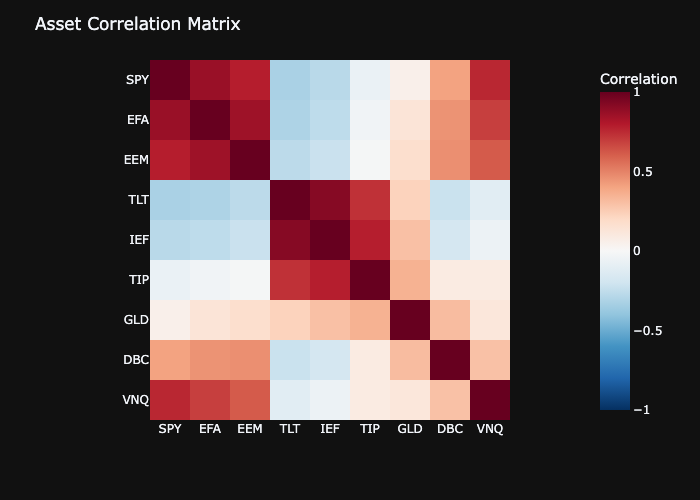

In [5]:
# Correlation heatmap
fig = px.imshow(
    corr_matrix,
    labels=dict(color="Correlation"),
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    aspect='equal'
)
fig.update_layout(
    title='Asset Correlation Matrix',
    template='plotly_dark',
    height=500
)
fig.show()


## 3. Portfolio Optimization Functions

In [6]:
def portfolio_volatility(weights, cov_matrix):
    """Calculate portfolio volatility."""
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

def risk_contribution(weights, cov_matrix):
    """Calculate marginal and total risk contribution."""
    port_vol = portfolio_volatility(weights, cov_matrix)
    marginal = np.dot(cov_matrix, weights) / port_vol
    total_rc = weights * marginal
    return total_rc

def risk_parity_objective(weights, cov_matrix):
    """Objective: minimize deviation from equal risk contribution."""
    rc = risk_contribution(weights, cov_matrix)
    target_rc = portfolio_volatility(weights, cov_matrix) / len(weights)
    return np.sum((rc - target_rc)**2)

def inverse_volatility_weights(cov_matrix):
    """Simple inverse volatility weighting."""
    vols = np.sqrt(np.diag(cov_matrix))
    inv_vols = 1 / vols
    return inv_vols / inv_vols.sum()

def risk_parity_optimization(cov_matrix, risk_budget=None):
    """Optimize for equal (or custom) risk contribution."""
    n = cov_matrix.shape[0]
    if risk_budget is None:
        risk_budget = np.ones(n) / n
    
    def objective(w):
        rc = risk_contribution(w, cov_matrix)
        port_vol = portfolio_volatility(w, cov_matrix)
        target = risk_budget * port_vol
        return np.sum((rc - target)**2)
    
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = [(0.01, 0.5) for _ in range(n)]
    x0 = np.ones(n) / n
    
    result = minimize(objective, x0, method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x

print("✓ Optimization functions defined")


✓ Optimization functions defined


## 4. Compare Portfolio Approaches

In [7]:
n_assets = len(returns_df.columns)

# Equal weight
w_equal = np.ones(n_assets) / n_assets

# Inverse volatility
w_invvol = inverse_volatility_weights(cov_matrix.values)

# Risk parity
w_rp = risk_parity_optimization(cov_matrix.values)

# Display weights
weights_df = pd.DataFrame({
    'Asset': returns_df.columns,
    'Equal Weight': w_equal * 100,
    'Inv Vol': w_invvol * 100,
    'Risk Parity': w_rp * 100
}).round(1)

print("Portfolio Weights (%):")
print(weights_df.to_string(index=False))


Portfolio Weights (%):
Asset  Equal Weight  Inv Vol  Risk Parity
  SPY          11.1      8.2          8.8
  EFA          11.1      7.5          7.4
  EEM          11.1      6.5          6.5
  TLT          11.1      9.1         17.9
  IEF          11.1     20.8         16.5
  TIP          11.1     24.0         16.3
  GLD          11.1      9.0         10.5
  DBC          11.1      8.1          9.3
  VNQ          11.1      6.7          6.7


In [8]:
# Risk contributions
rc_equal = risk_contribution(w_equal, cov_matrix.values)
rc_invvol = risk_contribution(w_invvol, cov_matrix.values)
rc_rp = risk_contribution(w_rp, cov_matrix.values)

# Normalize to percentage
rc_df = pd.DataFrame({
    'Asset': returns_df.columns,
    'Equal Weight': rc_equal / rc_equal.sum() * 100,
    'Inv Vol': rc_invvol / rc_invvol.sum() * 100,
    'Risk Parity': rc_rp / rc_rp.sum() * 100
}).round(1)

print("\nRisk Contributions (%):")
print(rc_df.to_string(index=False))



Risk Contributions (%):
Asset  Equal Weight  Inv Vol  Risk Parity
  SPY          16.2     12.7         11.8
  EFA          18.2     13.4         11.4
  EEM          21.0     13.4         11.9
  TLT           1.3      6.5         15.2
  IEF           1.1      7.9          6.9
  TIP           2.4     11.6          7.8
  GLD           8.4     10.6         12.3
  DBC          12.2     10.4         10.8
  VNQ          19.2     13.5         11.9


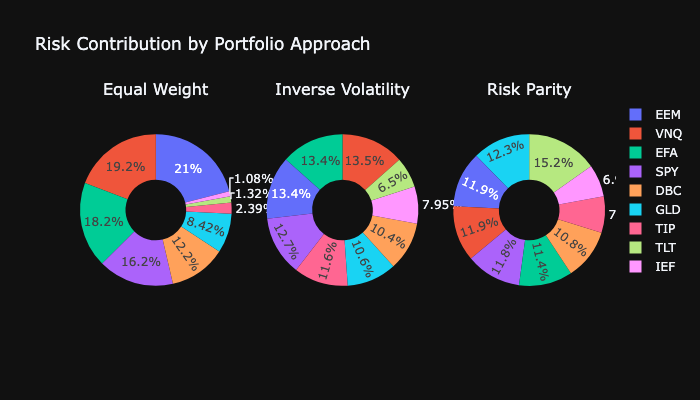

In [9]:
# Visualize risk contributions
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=['Equal Weight', 'Inverse Volatility', 'Risk Parity'],
    specs=[[{'type': 'pie'}, {'type': 'pie'}, {'type': 'pie'}]]
)

for i, (col, rc) in enumerate([
    ('Equal Weight', rc_equal),
    ('Inv Vol', rc_invvol),
    ('Risk Parity', rc_rp)
]):
    fig.add_trace(
        go.Pie(
            labels=returns_df.columns,
            values=rc / rc.sum(),
            hole=0.4,
            name=col
        ),
        row=1, col=i+1
    )

fig.update_layout(
    title='Risk Contribution by Portfolio Approach',
    template='plotly_dark',
    height=400
)
fig.show()


## 5. Hierarchical Risk Parity (HRP)

In [10]:
def hrp_weights(returns):
    """Hierarchical Risk Parity implementation."""
    # Step 1: Correlation-based distance
    corr = returns.corr()
    dist = np.sqrt(0.5 * (1 - corr))
    
    # Step 2: Hierarchical clustering
    dist_condensed = squareform(dist.values)
    link = linkage(dist_condensed, method='single')
    
    # Step 3: Quasi-diagonalization (seriation)
    def get_quasi_diag(link):
        link = link.astype(int)
        sort_ix = pd.Series([link[-1, 0], link[-1, 1]])
        num_items = link[-1, 3]
        while sort_ix.max() >= num_items:
            sort_ix.index = range(0, sort_ix.shape[0]*2, 2)
            df0 = sort_ix[sort_ix >= num_items]
            i = df0.index
            j = df0.values - num_items
            sort_ix[i] = link[j, 0]
            df1 = pd.Series(link[j, 1], index=i+1)
            sort_ix = pd.concat([sort_ix, df1]).sort_index()
            sort_ix.index = range(sort_ix.shape[0])
        return sort_ix.tolist()
    
    sort_ix = get_quasi_diag(link)
    sorted_assets = [returns.columns[i] for i in sort_ix]
    
    # Step 4: Recursive bisection
    cov = returns.cov() * 252
    
    def get_cluster_var(cov, items):
        cov_slice = cov.loc[items, items]
        w = inverse_volatility_weights(cov_slice.values)
        return portfolio_volatility(w, cov_slice.values)
    
    def recursive_bisection(cov, sorted_assets):
        weights = pd.Series(1.0, index=sorted_assets)
        clusters = [sorted_assets]
        
        while len(clusters) > 0:
            clusters = [c[j:k] for c in clusters 
                       for j, k in ((0, len(c)//2), (len(c)//2, len(c))) 
                       if len(c) > 1]
            for i in range(0, len(clusters), 2):
                c0, c1 = clusters[i], clusters[i+1]
                var0 = get_cluster_var(cov, c0)
                var1 = get_cluster_var(cov, c1)
                alpha = 1 - var0 / (var0 + var1)
                weights[c0] *= alpha
                weights[c1] *= 1 - alpha
        
        return weights
    
    return recursive_bisection(cov, sorted_assets)

# Calculate HRP weights
w_hrp = hrp_weights(returns_df)
w_hrp = w_hrp[returns_df.columns].values  # Reorder

print("\nHRP Weights:")
for asset, w in zip(returns_df.columns, w_hrp):
    print(f"  {asset}: {w*100:.1f}%")



HRP Weights:
  SPY: 7.5%
  EFA: 11.7%
  EEM: 6.0%
  TLT: 5.3%
  IEF: 12.1%
  TIP: 27.4%
  GLD: 13.9%
  DBC: 8.7%
  VNQ: 7.3%


## 6. Backtest Portfolio Strategies

In [11]:
# Calculate portfolio returns
portfolios = {
    'Equal Weight': w_equal,
    'Inverse Vol': w_invvol,
    'Risk Parity': w_rp,
    'HRP': w_hrp
}

port_returns = pd.DataFrame()
for name, weights in portfolios.items():
    port_returns[name] = (returns_df * weights).sum(axis=1)

# Cumulative returns
cumulative = (1 + port_returns).cumprod()


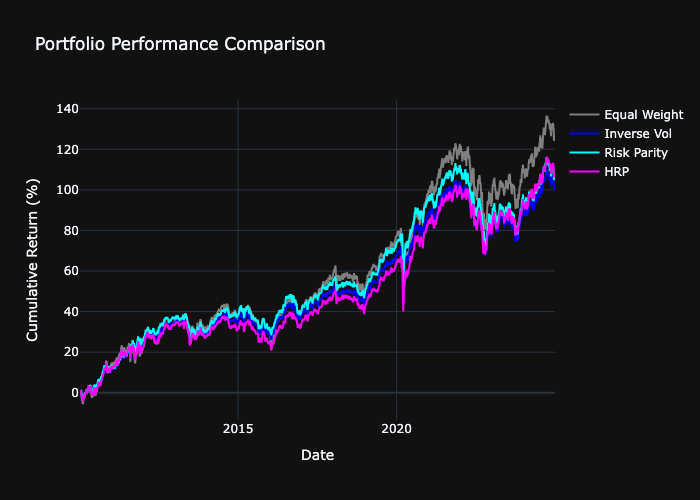

In [12]:
# Performance chart
fig = go.Figure()

colors = {'Equal Weight': 'gray', 'Inverse Vol': 'blue', 'Risk Parity': 'cyan', 'HRP': 'magenta'}

for col in cumulative.columns:
    fig.add_trace(go.Scatter(
        x=cumulative.index,
        y=(cumulative[col] - 1) * 100,
        mode='lines',
        name=col,
        line=dict(color=colors[col], width=2)
    ))

fig.update_layout(
    title='Portfolio Performance Comparison',
    xaxis_title='Date',
    yaxis_title='Cumulative Return (%)',
    template='plotly_dark',
    height=500
)
fig.show()


In [13]:
# Performance metrics
def calc_metrics(returns, name):
    total = (1 + returns).prod() - 1
    years = len(returns) / 252
    ann_ret = (1 + total) ** (1/years) - 1
    ann_vol = returns.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol
    
    cum = (1 + returns).cumprod()
    max_dd = ((cum.cummax() - cum) / cum.cummax()).max()
    calmar = ann_ret / max_dd if max_dd > 0 else 0
    
    return {
        'Portfolio': name,
        'Ann. Return': ann_ret * 100,
        'Ann. Vol': ann_vol * 100,
        'Sharpe': sharpe,
        'Max DD': max_dd * 100,
        'Calmar': calmar
    }

metrics = pd.DataFrame([calc_metrics(port_returns[col], col) for col in port_returns.columns])
print("\nPortfolio Performance Metrics:")
print(metrics.round(2).to_string(index=False))



Portfolio Performance Metrics:
   Portfolio  Ann. Return  Ann. Vol  Sharpe  Max DD  Calmar
Equal Weight         5.59      9.29    0.60   19.15    0.29
 Inverse Vol         4.78      7.00    0.68   17.98    0.27
 Risk Parity         4.94      7.39    0.67   19.46    0.25
         HRP         5.00      7.73    0.65   16.90    0.30


## 7. Leverage Targeting

In [14]:
# Target 10% volatility with leverage
target_vol = 0.10

leveraged_returns = pd.DataFrame()

for name, weights in portfolios.items():
    # Portfolio volatility
    port_vol = portfolio_volatility(weights, cov_matrix.values)
    leverage = target_vol / port_vol
    
    # Levered returns (assuming 2% borrowing cost)
    base_returns = (returns_df * weights).sum(axis=1)
    borrowing_cost = (leverage - 1) * 0.02 / 252 if leverage > 1 else 0
    leveraged_returns[f'{name} (L={leverage:.1f}x)'] = base_returns * leverage - borrowing_cost
    
    print(f"{name}: Vol={port_vol*100:.1f}%, Leverage={leverage:.2f}x")


Equal Weight: Vol=9.3%, Leverage=1.08x
Inverse Vol: Vol=7.0%, Leverage=1.43x
Risk Parity: Vol=7.4%, Leverage=1.35x
HRP: Vol=7.7%, Leverage=1.29x


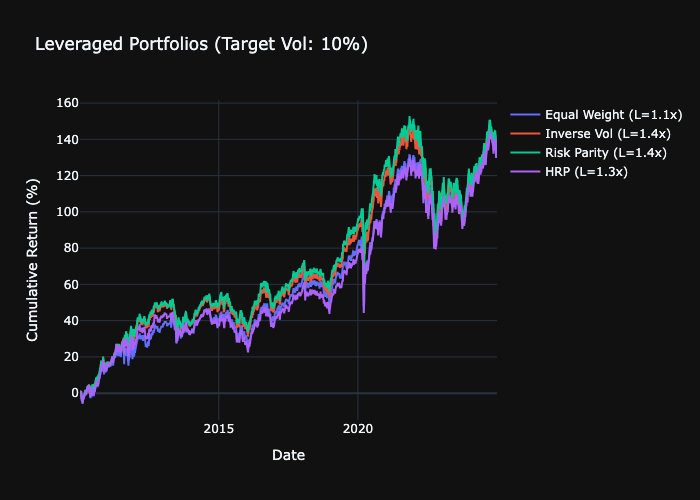

In [15]:
# Leveraged performance
lev_cumulative = (1 + leveraged_returns).cumprod()

fig = go.Figure()

for col in lev_cumulative.columns:
    fig.add_trace(go.Scatter(
        x=lev_cumulative.index,
        y=(lev_cumulative[col] - 1) * 100,
        mode='lines',
        name=col,
        line=dict(width=2)
    ))

fig.update_layout(
    title=f'Leveraged Portfolios (Target Vol: {target_vol*100:.0f}%)',
    xaxis_title='Date',
    yaxis_title='Cumulative Return (%)',
    template='plotly_dark',
    height=500
)
fig.show()


## 8. Summary Report

In [ ]:
print("="*70)
print("RISK PARITY PORTFOLIO ANALYSIS")
print("="*70)

print(f"\n1. UNIVERSE")
print(f"   Assets: {', '.join(returns_df.columns)}")
print(f"   Period: {returns_df.index.min().date()} to {returns_df.index.max().date()}")

print(f"\n2. BEST PORTFOLIO (by Sharpe)")
best = metrics.loc[metrics['Sharpe'].idxmax()]
print(f"   {best['Portfolio']}: {best['Ann. Return']:.1f}% return, {best['Sharpe']:.2f} Sharpe")

print(f"\n3. RISK PARITY BENEFITS")
print(f"   - Equal risk contribution across assets")
print(f"   - Lower concentration risk")
print(f"   - More stable through market regimes")

print(f"\n4. LEVERAGE ANALYSIS")
print(f"   Target volatility: {target_vol*100:.0f}%")
for name, weights in portfolios.items():
    port_vol = portfolio_volatility(weights, cov_matrix.values)
    leverage = target_vol / port_vol
    print(f"   {name}: {leverage:.2f}x leverage needed")

print("\n" + "="*70)


RISK PARITY PORTFOLIO ANALYSIS

1. UNIVERSE
   Assets: SPY, EFA, EEM, TLT, IEF, TIP, GLD, DBC, VNQ
   Period: 2010-01-05 to 2024-12-31

2. BEST PORTFOLIO (by Sharpe)
   Inverse Vol: 4.8% return, 0.68 Sharpe

3. RISK PARITY BENEFITS
   - Equal risk contribution across assets
   - Lower concentration risk
   - More stable through market regimes

4. LEVERAGE ANALYSIS
   Target volatility: 10%
   Equal Weight: 1.08x leverage needed
   Inverse Vol: 1.43x leverage needed
   Risk Parity: 1.35x leverage needed
   HRP: 1.29x leverage needed



: 

## Summary

This CQF-level example covered:

1. **Risk Parity Optimization**: Equal risk contribution
2. **Inverse Volatility**: Simple volatility-based weighting
3. **Hierarchical Risk Parity (HRP)**: ML-based allocation
4. **Risk Budgeting**: Custom risk allocations
5. **Leverage Targeting**: Vol-targeting for return enhancement
6. **Performance Comparison**: Sharpe, Calmar, Max DD

**Family Office Applications**:
- Strategic asset allocation
- Risk-aware portfolio construction
- Leverage management
- Multi-asset diversification